## Sentiment Analysis

In [1]:
#!python -m textblob.download_corpora

from textblob import TextBlob

review = "this has been done so many times!the acting and effects were diabolical, really poor.slow and dragged out, "

TextBlob(review).sentiment

Sentiment(polarity=0.2333333333333333, subjectivity=0.2333333333333333)

In [2]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


False

In [3]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sia.polarity_scores("cher is great in this movie. she should be nominated for the academy award for best actress.")

[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:997)>


{'neg': 0.0, 'neu': 0.543, 'pos': 0.457, 'compound': 0.9153}

In [4]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, use_safetensors=False)

classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

classifier("i wanted to try to like this movie, but it was so slow, and boring")

/Users/alexandraflores/nlp_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 17693.18it/s]


[{'label': 'NEGATIVE', 'score': 0.9995836615562439}]

In [8]:
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    model_kwargs={"use_safetensors": False}
)

classifier("george miller's happy feet is an exuberant, beautifully animated film and, by a wide margin, the best cg film ever made")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 23116.46it/s]


[{'label': 'POSITIVE', 'score': 0.9998756647109985}]

## SETUP 

In [5]:
!pip -q install textblob vaderSentiment transformers accelerate sentencepiece spacy --upgrade
!python -m textblob.download_corpora > /dev/null 2>&1
!python -m spacy download en_core_web_sm > /dev/null 2>&1

In [6]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import spacy

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Load the Dataset (2000 reviews)

In [7]:
# load 2000 clean movie reviews

DATA_PATH = "/Users/alexandraflores/Desktop/movie_reviews_clean_2000.csv"
TEXT_COL = "clean_reviews"

In [8]:
import os

#read file
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    if TEXT_COL not in df.columns:
        raise ValueError(f"Expected a '{TEXT_COL}' column — rename your text column or update TEXT_COL.")
    print(f"Loaded {len(df)} reviews from {DATA_PATH}")

  

df.head()

Loaded 2000 reviews from /Users/alexandraflores/Desktop/movie_reviews_clean_2000.csv


,clean_movie_name,movie_name,movie_name_metadata,user_rating,movie_score,emotion,clean_reviews,clean_genre,clean_overview,clean_description,...,tfidf_say,tfidf_scenes,tfidf_see,tfidf_story,tfidf_think,tfidf_time,tfidf_two,tfidf_watch,tfidf_way,tfidf_well
0,the dictator,The Dictator,The Dictator,10.0,62.0,sadness,"i wish there were more comedies like that - crossing over the political correctness line, but not over the line of g...",comedy,the heroic story of a dictator who risks his life to ensure that democracy would never come to the country he so lov...,"pursued by a cab driver for an unpaid fare, a millionaire's son, brooke travers (wallace reid), hides on a steamer, ...",...,0.000000,0.0,0.206251,0.000000,0.0,0.000000,0.0,0.253051,0.000000,0.211851
1,the assignment,The Assignment,The Assignment,3.0,55.0,anticipation,"for a film that is strangely underwhelming and completely unknown to the public, the assignment, is a very horrendou...","action, crime, thriller",ace assassin frank kitchen is double crossed by gangsters and falls into the hands of rogue surgeon known as the doc...,"obie (erica marks) is second-in-command in the vigils, an established student secret society at trinity high school....",...,0.177358,0.0,0.000000,0.134083,0.0,0.139404,0.0,0.000000,0.000000,0.000000
2,big game,Big Game,Big Game,3.0,55.0,joy,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...","action, adventure, thriller","air force one is shot down by terrorists, leaving the president of the united states stranded in the wilderness. 13-...","larry winthrop, the pampered son of an aristocratic boston family, is loved by his wife, eleanor, but she wants him ...",...,0.000000,0.0,0.000000,0.000000,0.0,0.213408,0.0,0.000000,0.000000,0.214268
3,sixteen candles,Sixteen Candles,Sixteen Candles,7.0,68.0,sadness,"movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so music...","comedy, romance",a teenage girl deals with her parents forgetting her birthday and a crush on her high school's heartthrob.,"a girl's ""sweet"" sixteenth birthday is anything but special: her family forgets about it, and she suffers from every...",...,0.000000,0.0,0.000000,0.078997,0.0,0.082132,0.0,0.000000,0.095145,0.000000
4,the sorcerer's apprentice,The Sorcerer's Apprentice,The Sorcerer's Apprentice,8.0,61.0,fear,jay b. is funny and charming in a believably nerdy fashion; cage is at his quirky but charismatic best; the effects ...,"fantasy, adventure, action","balthazar blake is a master sorcerer in modern-day manhattan trying to defend the city from his arch-nemesis, maxim ...","a young boy becomes an apprentice for a mysterious sorcerer, working at the sorcerer's strange and sinister mill whe...",...,0.000000,0.0,0.181887,0.178973,0.0,0.000000,0.0,0.000000,0.000000,0.186826


In [ ]:
#get the info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 87 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   clean_movie_name                     2000 non-null   object 
 1   movie_name                           2000 non-null   object 
 2   movie_name_metadata                  2000 non-null   object 
 3   user_rating                          2000 non-null   float64
 4   movie_score                          2000 non-null   float64
 5   emotion                              2000 non-null   object 
 6   clean_reviews                        2000 non-null   object 
 7   clean_genre                          2000 non-null   object 
 8   clean_overview                       2000 non-null   object 
 9   clean_description                    2000 non-null   object 
 10  budget                               2000 non-null   float64
 11  revenue                       

In [ ]:
# Quick recap-level EDA 
print("Rows:", len(df))
print("Movie names", df['clean_movie_name'].nunique())
df['clean_reviews'].str.len().describe()

Rows: 2000
Movie names 712


count    2000.000000
mean     1414.650500
std      1077.463895
min        53.000000
25%       712.750000
50%      1008.000000
75%      1757.500000
max      6193.000000
Name: clean_reviews, dtype: float64

In [ ]:
#add primary genre column 
df['primary_genre'] = df['clean_genre'].apply(lambda x: x.split(",")[0].strip())

In [32]:
df.head()

,clean_movie_name,movie_name,movie_name_metadata,user_rating,movie_score,emotion,clean_reviews,clean_genre,clean_overview,clean_description,...,tfidf_think,tfidf_time,tfidf_two,tfidf_watch,tfidf_way,tfidf_well,tb_polarity,tb_subjectivity,tb_label,primary_genre
0,the dictator,The Dictator,The Dictator,10.0,62.0,sadness,"i wish there were more comedies like that - crossing over the political correctness line, but not over the line of g...",comedy,the heroic story of a dictator who risks his life to ensure that democracy would never come to the country he so lov...,"pursued by a cab driver for an unpaid fare, a millionaire's son, brooke travers (wallace reid), hides on a steamer, ...",...,0.0,0.000000,0.0,0.253051,0.000000,0.211851,0.077564,0.726282,positive,comedy
1,the assignment,The Assignment,The Assignment,3.0,55.0,anticipation,"for a film that is strangely underwhelming and completely unknown to the public, the assignment, is a very horrendou...","action, crime, thriller",ace assassin frank kitchen is double crossed by gangsters and falls into the hands of rogue surgeon known as the doc...,"obie (erica marks) is second-in-command in the vigils, an established student secret society at trinity high school....",...,0.0,0.139404,0.0,0.000000,0.000000,0.000000,-0.112029,0.505797,negative,action
2,big game,Big Game,Big Game,3.0,55.0,joy,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...","action, adventure, thriller","air force one is shot down by terrorists, leaving the president of the united states stranded in the wilderness. 13-...","larry winthrop, the pampered son of an aristocratic boston family, is loved by his wife, eleanor, but she wants him ...",...,0.0,0.213408,0.0,0.000000,0.000000,0.214268,-0.057986,0.454080,negative,action
3,sixteen candles,Sixteen Candles,Sixteen Candles,7.0,68.0,sadness,"movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so music...","comedy, romance",a teenage girl deals with her parents forgetting her birthday and a crush on her high school's heartthrob.,"a girl's ""sweet"" sixteenth birthday is anything but special: her family forgets about it, and she suffers from every...",...,0.0,0.082132,0.0,0.000000,0.095145,0.000000,0.270263,0.547719,positive,comedy
4,the sorcerer's apprentice,The Sorcerer's Apprentice,The Sorcerer's Apprentice,8.0,61.0,fear,jay b. is funny and charming in a believably nerdy fashion; cage is at his quirky but charismatic best; the effects ...,"fantasy, adventure, action","balthazar blake is a master sorcerer in modern-day manhattan trying to defend the city from his arch-nemesis, maxim ...","a young boy becomes an apprentice for a mysterious sorcerer, working at the sorcerer's strange and sinister mill whe...",...,0.0,0.000000,0.0,0.000000,0.000000,0.186826,0.242601,0.566263,positive,fantasy


## Lexicon Based Sentiment Analysis 

In [ ]:
#put clean reviews into textblob 
def textblob_scores(text):
    blob = TextBlob(str(text))
    return pd.Series({"tb_polarity": blob.sentiment.polarity,
                       "tb_subjectivity": blob.sentiment.subjectivity})

df[["tb_polarity", "tb_subjectivity"]] = df["clean_reviews"].apply(textblob_scores)

def label_from_polarity(p, pos_thresh=0.05, neg_thresh=-0.05):
    if p >= pos_thresh:
        return "positive"
    elif p <= neg_thresh:
        return "negative"
    return "neutral"

df["tb_label"] = df["tb_polarity"].apply(label_from_polarity)
df[["clean_reviews", "tb_polarity", "tb_subjectivity", "tb_label"]].head()

#textBlob labels the review as positive or negative with a tb polarity score. 

,clean_reviews,tb_polarity,tb_subjectivity,tb_label
0,"i wish there were more comedies like that - crossing over the political correctness line, but not over the line of g...",0.077564,0.726282,positive
1,"for a film that is strangely underwhelming and completely unknown to the public, the assignment, is a very horrendou...",-0.112029,0.505797,negative
2,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",-0.057986,0.454080,negative
3,"movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so music...",0.270263,0.547719,positive
4,jay b. is funny and charming in a believably nerdy fashion; cage is at his quirky but charismatic best; the effects ...,0.242601,0.566263,positive


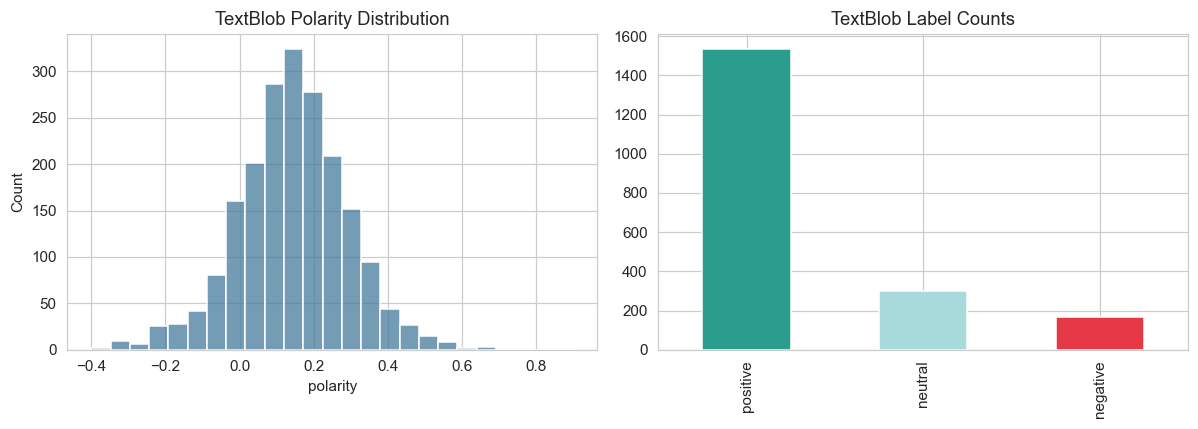

In [13]:
#plot textblob polarity distribution and textblob label counts
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["tb_polarity"], bins=25, ax=axes[0], color="#457B9D")
axes[0].set_title("TextBlob Polarity Distribution")
axes[0].set_xlabel("polarity")

df["tb_label"].value_counts().reindex(["positive", "neutral", "negative"]).plot(
    kind="bar", ax=axes[1], color=["#2A9D8F", "#A8DADC", "#E63946"])
axes[1].set_title("TextBlob Label Counts")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

## VADER 

In [ ]:
#just an example
sia = SentimentIntensityAnalyzer()

sample_review_2 = "this has been done so many times! the acting and effects were diabolical, really poor and slow."
print(sia.polarity_scores(sample_review_2))

#Overall negative review

{'neg': 0.187, 'neu': 0.813, 'pos': 0.0, 'compound': -0.5697}


In [99]:
#put clean reviews into vader function
def vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return pd.Series({"vader_neg": scores["neg"], "vader_neu": scores["neu"],
                       "vader_pos": scores["pos"], "vader_compound": scores["compound"]})

df[["vader_neg", "vader_neu", "vader_pos", "vader_compound"]] = df["clean_reviews"].apply(vader_scores)

def label_from_compound(c, pos_thresh=0.05, neg_thresh=-0.05):
    if c >= pos_thresh:
        return "positive"
    elif c <= neg_thresh:
        return "negative"
    return "neutral"

df["vader_label"] = df["vader_compound"].apply(label_from_compound)
df[["clean_reviews", "vader_compound", "vader_label"]].head()

#labels reviews as positive or negative based on the vader compound

,clean_reviews,vader_compound,vader_label
0,"i wish there were more comedies like that - crossing over the political correctness line, but not over the line of g...",0.9683,positive
1,"for a film that is strangely underwhelming and completely unknown to the public, the assignment, is a very horrendou...",-0.9729,negative
2,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",-0.4929,negative
3,"movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so music...",0.9961,positive
4,jay b. is funny and charming in a believably nerdy fashion; cage is at his quirky but charismatic best; the effects ...,0.9952,positive


## TextBlob vs Vader

In [ ]:
#test accuracy on some examples
stress_test = [
    "king kong (1976) was a total waste of time and money from the always bankrupt producer",
    "bambi is a good movie. not only is it effective in occupying the kids for an hour, but it has an emotional impact",
    "this movie was sick",       # slang: "sick" = great
    "you will enjoy this movie if you enjoy trashy movies.",  # sarcasm
    "this movie was actually the worst movie i have seen. nothing interesting happened.",
]

rows = []
for t in stress_test:
    tb = TextBlob(t).sentiment
    vs = sia.polarity_scores(t)
    rows.append({"text": t, "TextBlob polarity": round(tb.polarity, 2),
                 "VADER compound": round(vs["compound"], 2)})

pd.DataFrame(rows)

#the table shows the comparison with the TextBlob polarity and Vader compound results. VADER shows better results and scores sentiment more strongly. Also important to note that both are unable to detect slang and sarcasm. 

,text,TextBlob polarity,VADER compound
0,king kong (1976) was a total waste of time and money from the always bankrupt producer,-0.10,-0.77
1,"bambi is a good movie. not only is it effective in occupying the kids for an hour, but it has an emotional impact",0.32,0.60
2,this movie was sick,-0.71,-0.51
3,you will enjoy this movie if you enjoy trashy movies.,0.40,0.75
4,this movie was actually the worst movie i have seen. nothing interesting happened.,-0.17,-0.75


In [101]:
agreement = (df["tb_label"] == df["vader_label"]).mean()
print(f"TextBlob and VADER agree on {agreement:.1%} of reviews in this dataset.")
pd.crosstab(df["tb_label"], df["vader_label"])

TextBlob and VADER agree on 77.6% of reviews in this dataset.


vader_label,negative,neutral,positive
tb_label,,,
negative,137,1,29
neutral,113,7,179
positive,122,3,1409


## Transformer Based Sentiment Analysis 

In [106]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print("Using GPU" if device == 0 else "Using CPU (Runtime > Change runtime type > GPU for a speed-up)")

Using CPU (Runtime > Change runtime type > GPU for a speed-up)


### Bert Sentiment Classifier

In [118]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, use_safetensors=False)

bert_clf = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

bert_clf("The movie exceeded all our expectations.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 22719.15it/s]


[{'label': 'POSITIVE', 'score': 0.99919193983078}]

In [119]:
#use a sample of 15 clean reviews for the bert function
bert_sample = df["clean_reviews"].sample(15, random_state=RANDOM_SEED).tolist()
bert_results = bert_clf(bert_sample, truncation=True)

for text, res in zip(bert_sample, bert_results):
    print(f"[{res['label']:>8} {res['score']:.2f}]  {text[:90]}")

#bert labels the reviews as either positive or negative and model confidence in that label. 

[NEGATIVE 1.00]  this was a terrible movie. some of the parts are so stupid & silly that i found myself lau
[NEGATIVE 0.99]  i saw this film a few weeks ago, and i enjoyed it but i really dont think it deserves a 7.
[POSITIVE 1.00]  this short film constitutes an amazing cutting, an incredible edition inside the mind of a
[NEGATIVE 0.60]  this entry in ¨vigilante genre¨ contains amount of action and excessive violence. it conce
[NEGATIVE 0.97]  shortly as always; acting isn't too good.. sounds that people produce seem artificial. thi
[POSITIVE 1.00]  a young woman searches for love in new york city in this enjoyable romantic comedy based o
[NEGATIVE 0.99]  honestly stick with the animation, it was a zillion time better then the real life movie.w
[NEGATIVE 1.00]  there are risks when romantic comedy is injected with "truth." too little, and it feels li
[POSITIVE 0.99]  a modern-day film noir, this is about as tough as it gets. rough characters, rough violenc
[POSITIVE 1.00]  i can see h

In [116]:
# Run over the full dataset (batched, and truncated to BERT's max sequence length)
bert_full = bert_clf(df["clean_reviews"].tolist(), truncation=True, batch_size=32)
df["bert_label"] = [r["label"].lower() for r in bert_full]
df["bert_score"] = [r["score"] for r in bert_full]
df[["clean_reviews", "bert_label", "bert_score"]].head()

,clean_reviews,bert_label,bert_score
0,"i wish there were more comedies like that - crossing over the political correctness line, but not over the line of g...",positive,0.999278
1,"for a film that is strangely underwhelming and completely unknown to the public, the assignment, is a very horrendou...",negative,0.999726
2,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",negative,0.986391
3,"movies in the 80's were really cool, nice story lines, very real people and cute guys too! 80's movies were so music...",positive,0.999688
4,jay b. is funny and charming in a believably nerdy fashion; cage is at his quirky but charismatic best; the effects ...,positive,0.999596


In [ ]:
#putting a mixed review example to see how VADER and BERT compare, context is needed for this example
mixed = "i love chick flicks and i love patrick dempsey...and i was so disappointed with this film it sucked...the humorous parts were not funny at all.,"
print("VADER compound:", sia.polarity_scores(mixed)["compound"])
print("BERT:", bert_clf(mixed))

#BERT was more accurate for this example

VADER compound: 0.6811
BERT: [{'label': 'NEGATIVE', 'score': 0.9997726082801819}]


## Comparing Methods 

In [ ]:
#use a random sample to compare the methods and see which one is more accurate
compare_sample = df.sample(15, random_state=RANDOM_SEED).copy()
compare_sample["clean_reviews"] = compare_sample["clean_reviews"].str.slice(0, 70) + "..."
compare_sample[["clean_reviews", "tb_label", "vader_label", "bert_label"]]

#BERT is more accurate than vader and tb accoring to the sample 

,clean_reviews,tb_label,vader_label,bert_label
1860,this was a terrible movie. some of the parts are so stupid & silly tha...,negative,positive,negative
353,"i saw this film a few weeks ago, and i enjoyed it but i really dont th...",positive,positive,negative
1333,"this short film constitutes an amazing cutting, an incredible edition ...",positive,positive,positive
905,this entry in ¨vigilante genre¨ contains amount of action and excessiv...,positive,negative,negative
1289,shortly as always; acting isn't too good.. sounds that people produce ...,positive,positive,negative
1273,a young woman searches for love in new york city in this enjoyable rom...,positive,positive,positive
938,"honestly stick with the animation, it was a zillion time better then t...",positive,positive,negative
1731,"there are risks when romantic comedy is injected with ""truth."" too lit...",positive,positive,negative
65,"a modern-day film noir, this is about as tough as it gets. rough chara...",neutral,negative,positive
1323,i can see how some people wouldn't like the movie. it didn't have alot...,positive,positive,positive


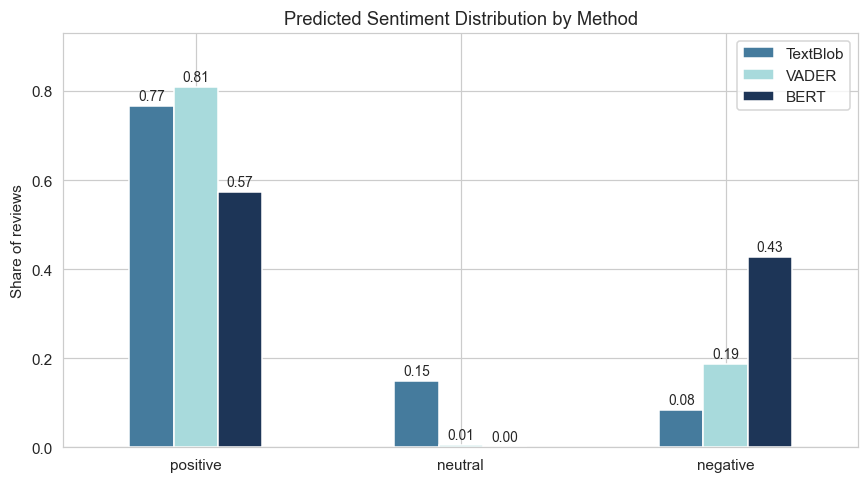

In [ ]:
#count the labels for textblob,VADER, and BERT and compare
label_counts = pd.DataFrame({
    "TextBlob": df["tb_label"].value_counts(normalize=True),
    "VADER": df["vader_label"].value_counts(normalize=True),
    "BERT": df["bert_label"].value_counts(normalize=True),
}).reindex(["positive", "neutral", "negative"]).fillna(0)

ax = label_counts.plot(kind="bar", figsize=(8, 4.5), color=["#457B9D", "#A8DADC", "#1D3557"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=9)

plt.title("Predicted Sentiment Distribution by Method")
plt.ylabel("Share of reviews")
plt.xticks(rotation=0)
plt.ylim(0, label_counts.values.max() * 1.15)  # headroom so labels don't get clipped
plt.tight_layout()
plt.show()

#the barchart portrays that the BERT model had a higher negative sentiment rate compared to the others. 

## Aspect-Based Sentiment Analysis 

In [17]:
import spacy

In [23]:
nlp = spacy.load("en_core_web_sm")

def segment_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

example = df["clean_reviews"].iloc[0]
print(example)
print("---")
segment_sentences(example)

i wish there were more comedies like that - crossing over the political correctness line, but not over the line of good taste, so as to make a movie hard to watch.the film is quite pointy, it is for a moderate audience and will make all kinds of extremists quite unhappy. the plot is well thought out and funny. it'll nail you to the screen.i like the unorthodox character of this film, sacha baron cohen's movies are definitely one of the kind. i wouldn't consider the humor crude, but it is certainly honest. some of the unthinkable things you see are likely to have happened in reality.
---


['i wish there were more comedies like that - crossing over the political correctness line, but not over the line of good taste, so as to make a movie hard to watch.the film is quite pointy, it is for a moderate audience and will make all kinds of extremists quite unhappy.',
 'the plot is well thought out and funny.',
 "it'll nail you to the screen.i like the unorthodox character of this film, sacha baron cohen's movies are definitely one of the kind.",
 "i wouldn't consider the humor crude, but it is certainly honest.",
 'some of the unthinkable things you see are likely to have happened in reality.']

In [ ]:
#use functions to filter reviews 
def has_noun_phrase(sent, nlp_doc=None):
    doc = nlp_doc if nlp_doc is not None else nlp(sent)
    return any(chunk for chunk in doc.noun_chunks)

def filter_sentences(sentences, min_words=3):
    kept = []
    for s in sentences:
        n_words = len(s.split())
        if n_words >= min_words:
            kept.append(s)
        elif has_noun_phrase(s):
            kept.append(s)  
    return kept

test_sentences = ["Ok.", "Loved it.", "Great movie.", "The movie was interesting."]
print("Before filter:", test_sentences)
print("After filter: ", filter_sentences(test_sentences))


Before filter: ['Ok.', 'Loved it.', 'Great movie.', 'The movie was interesting.']
After filter:  ['Loved it.', 'Great movie.', 'The movie was interesting.']


In [ ]:
#add aspect keywords for aspect based analysis
ASPECT_KEYWORDS = {
    "acting/performance": ["acting", "performance", "performances", "actor", "actors", "actress", "cast", "casting", "played", "portrayal", "role", "character", "actor", "chemistry", "convincing", "believable"],
    "plot/story":    ["plot", "story", "storyline", "narrative", "script", "screenplay", "writing", "written", "twist", "pacing", "predictable", "plot holes", "ending", "climax", "subplot"],
    "directing":        ["director", "directing", "direction", "vision", "directed", "filmmaker", "filmmaking"],
    "visuals/cinematography":       ["cinematography", "visuals", "camera", "shot", "shots", "scenery", "framing", "lighting", "colors", "imagery", "visually"],
    "special effects/cgi":       ["effects", "cgi", "special effects", "visual effects", "graphics", "animation", "green screen", "practical effects"],
}

def match_aspects(sentence, keywords=ASPECT_KEYWORDS):
    s_lower = sentence.lower()
    matched = [aspect for aspect, kws in keywords.items() if any(kw in s_lower for kw in kws)]
    return matched

In [ ]:
#BERT helepr function
def bert_score(sent):
    result = bert_clf(sent, truncation=True)[0]
    score = result["score"]
    if result["label"] == "NEGATIVE":
        score = -score
    return score

In [162]:
#put clean genre, movie and review into the function (using BERT)
def absa_for_review_bert(primary_genre, clean_movie_name, text):
    sentences = segment_sentences(text)
    sentences = filter_sentences(sentences)
    records = []
    for sent in sentences:
        aspects = match_aspects(sent)
        if not aspects:
            continue
        compound = bert_score(sent)
        for aspect in aspects:
            records.append({
                "primary_genre": primary_genre, "clean_movie_name": clean_movie_name,
                "sentence": sent, "aspect": aspect, "sentiment": compound,
            })
    return records

absa_records = []
for _, row in df.iterrows():
    absa_records.extend(absa_for_review_bert(row["primary_genre"], row["clean_movie_name"], row["clean_reviews"]))

absa_df_bert = pd.DataFrame(absa_records)
print(f"{len(absa_df_bert)} aspect-level sentiment mentions extracted from {len(df)} reviews.")
absa_df_bert.head(10)

8504 aspect-level sentiment mentions extracted from 2000 reviews.


,primary_genre,clean_movie_name,sentence,aspect,sentiment
0,comedy,the dictator,the plot is well thought out and funny.,plot/story,0.999878
1,comedy,the dictator,"it'll nail you to the screen.i like the unorthodox character of this film, sacha baron cohen's movies are definitely...",acting/performance,0.999835
2,action,the assignment,it's a whirlwind of strange and odd fights alongside its vague and grim story about gender-change.,plot/story,0.563771
3,action,the assignment,"there wasn't anything else i found remotely exciting, not to mention that they have given weaver one of the worst sc...",acting/performance,-0.999784
4,action,the assignment,"there wasn't anything else i found remotely exciting, not to mention that they have given weaver one of the worst sc...",plot/story,-0.999784
5,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",acting/performance,-0.997498
6,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",plot/story,-0.997498
7,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",visuals/cinematography,-0.997498
8,action,big game,"the dumbness is introduced in the first few minutes and after that, refuses to clear out from the screenplay that is...",plot/story,-0.999187
9,action,big game,"that there is a cue for essential time managers to leave the seat and go home, never to return.big game has some del...",visuals/cinematography,0.999844


In [133]:
#put clean genre, movie and review into the function (using vader)
def absa_for_review(primary_genre, clean_movie_name, text):
    sentences = segment_sentences(text)
    sentences = filter_sentences(sentences)
    records = []
    for sent in sentences:
        aspects = match_aspects(sent)
        if not aspects:
            continue
        compound = sia.polarity_scores(sent)["compound"]
        for aspect in aspects:
            records.append({
                "primary_genre": primary_genre, "clean_movie_name": clean_movie_name,
                "sentence": sent, "aspect": aspect, "sentiment": compound,
            })
    return records

absa_records = []
for _, row in df.iterrows():
    absa_records.extend(absa_for_review(row["primary_genre"], row["clean_movie_name"], row["clean_reviews"]))

absa_df = pd.DataFrame(absa_records)
print(f"{len(absa_df)} aspect-level sentiment mentions extracted from {len(df)} reviews.")
absa_df.head(10)

8504 aspect-level sentiment mentions extracted from 2000 reviews.


,primary_genre,clean_movie_name,sentence,aspect,sentiment
0,comedy,the dictator,the plot is well thought out and funny.,plot/story,0.6124
1,comedy,the dictator,"it'll nail you to the screen.i like the unorthodox character of this film, sacha baron cohen's movies are definitely...",acting/performance,0.8225
2,action,the assignment,it's a whirlwind of strange and odd fights alongside its vague and grim story about gender-change.,plot/story,-0.8720
3,action,the assignment,"there wasn't anything else i found remotely exciting, not to mention that they have given weaver one of the worst sc...",acting/performance,-0.2263
4,action,the assignment,"there wasn't anything else i found remotely exciting, not to mention that they have given weaver one of the worst sc...",plot/story,-0.2263
5,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",acting/performance,0.3728
6,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",plot/story,0.3728
7,action,big game,"comic book violence with gleaming visuals apart, this finnish action-adventure has doses of ridiculousness scattered...",visuals/cinematography,0.3728
8,action,big game,"the dumbness is introduced in the first few minutes and after that, refuses to clear out from the screenplay that is...",plot/story,-0.2023
9,action,big game,"that there is a cue for essential time managers to leave the seat and go home, never to return.big game has some del...",visuals/cinematography,0.6249


In [147]:
# Aggregate: average sentiment per aspect, across all listings (BERT)
aspect_summary_bert = absa_df_bert.groupby("aspect")["sentiment"].agg(["mean", "count"]).sort_values("mean")
aspect_summary_bert

,mean,count
aspect,,
plot/story,0.054052,2962
special effects/cgi,0.176695,274
directing,0.184659,744
acting/performance,0.208012,3985
visuals/cinematography,0.321918,539


In [149]:
# Aggregate: average sentiment per aspect for each genre, across all listings
aspect_summary_genres_bert = absa_df_bert.groupby(["primary_genre","aspect"])["sentiment"].agg(["mean", "count"]).sort_values("mean")
aspect_summary_genres_bert

,,mean,count
primary_genre,aspect,,
tv movie,visuals/cinematography,-0.854225,1
documentary,acting/performance,-0.353976,4
science fiction,visuals/cinematography,-0.328819,6
action,plot/story,-0.199007,288
science fiction,plot/story,-0.181835,68
...,...,...,...
tv movie,directing,0.999681,2
mystery,special effects/cgi,0.999823,1
western,directing,0.999844,1


In [169]:
#pivot table for genre, aspects, and sentiment
pivot_mean_bert = absa_df_bert.pivot_table(
    index="primary_genre",
    columns="aspect",
    values="sentiment",
    aggfunc=("mean")
)

pivot_count_bert = absa_df_bert.pivot_table(
    index="primary_genre",
    columns="aspect",
    values="sentiment",
    aggfunc="count"
)

pivot_mean_bert

aspect,acting/performance,directing,plot/story,special effects/cgi,visuals/cinematography
primary_genre,,,,,
action,0.052036,-0.113122,-0.199007,0.124952,-0.000733
adventure,0.356604,0.207806,0.167964,0.102993,0.338440
animation,0.396799,-0.137981,0.198716,0.313801,0.601103
comedy,0.255629,0.190646,0.113247,0.086686,0.270492
crime,0.304720,0.290719,0.217673,0.000444,0.658169
documentary,-0.353976,NaN,-0.015601,0.999376,0.998819
drama,0.171259,0.235637,0.032962,0.415449,0.333332
family,-0.121002,0.065423,-0.121344,-0.094215,0.475356
fantasy,0.220780,0.509896,0.282413,0.119862,0.510159


In [165]:
pivot_count_bert

aspect,acting/performance,directing,plot/story,special effects/cgi,visuals/cinematography
primary_genre,,,,,
action,355.0,66.0,288.0,50.0,74.0
adventure,195.0,42.0,132.0,25.0,45.0
animation,76.0,14.0,82.0,40.0,15.0
comedy,1280.0,166.0,809.0,26.0,76.0
crime,90.0,14.0,69.0,2.0,12.0
documentary,4.0,NaN,2.0,1.0,4.0
drama,1000.0,215.0,777.0,28.0,166.0
family,84.0,15.0,59.0,13.0,12.0
fantasy,156.0,29.0,116.0,27.0,21.0


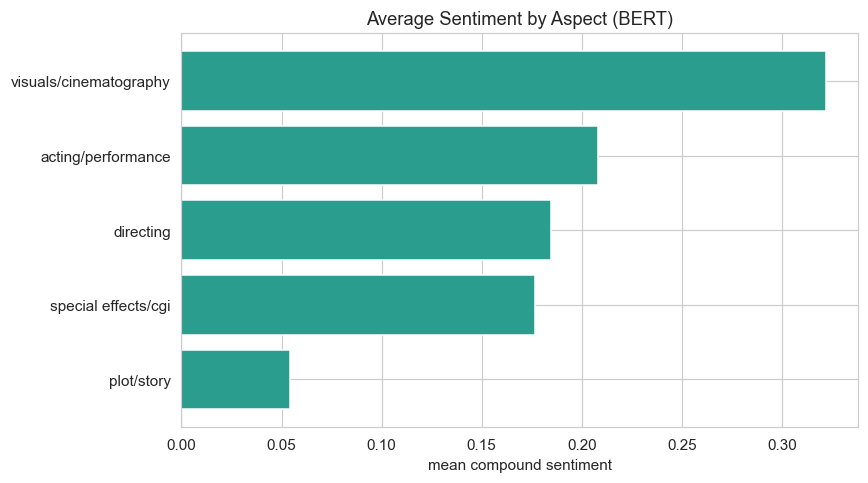

In [153]:
plt.figure(figsize=(8, 4.5))
colors = ["#E63946" if v < 0 else "#2A9D8F" for v in aspect_summary_bert["mean"]]
plt.barh(aspect_summary_bert.index, aspect_summary_bert["mean"], color=colors)
plt.axvline(0, color="#1D3557", linewidth=1)
plt.title("Average Sentiment by Aspect (BERT)")
plt.xlabel("mean compound sentiment")
plt.tight_layout()
plt.show()

##### These results give us insights to the average sentiment by aspect. Visuals and Cinematography has the highest mean compound sentiment, with acting/performance second, directing third, special effects/cgi, and lastly plot/story. This essentially means that IMDB movie reviewers appreciated or had higher positive reviews/ enjoyed movies with aspects such as visuals and cinematography, acting performance, directing, special effects/cgi, and plot/story. 

In [ ]:
# Per-listing aspect sentiment showing only genres of interest
genres_interest=['action','adventure','comedy','romance','horror','fantasy','thriller']
primary_genre_aspect = absa_df_bert.pivot_table(index="primary_genre", columns="aspect", values="sentiment", aggfunc="mean")
primary_genre_aspect.loc[genres_interest]

aspect,acting/performance,directing,plot/story,special effects/cgi,visuals/cinematography
primary_genre,,,,,
action,0.052036,-0.113122,-0.199007,0.124952,-0.000733
adventure,0.356604,0.207806,0.167964,0.102993,0.338440
comedy,0.255629,0.190646,0.113247,0.086686,0.270492
romance,0.346909,0.184735,0.244158,0.251669,0.675647
horror,0.164661,0.116088,-0.048985,0.294919,0.258594
fantasy,0.220780,0.509896,0.282413,0.119862,0.510159
thriller,0.065174,0.004214,-0.132405,-0.010635,0.099132


In [144]:
# Per-listing aspect sentiment — useful for a host-facing dashboard
movie_review_aspect = absa_df_bert.pivot_table(index="clean_movie_name", columns="aspect", values="sentiment", aggfunc="mean")
movie_review_aspect.head()

aspect,acting/performance,directing,plot/story,special effects/cgi,visuals/cinematography
clean_movie_name,,,,,
10 things i hate about you,0.147509,NaN,0.428489,NaN,NaN
100 girls,-0.710468,0.997288,-0.500055,NaN,NaN
12 rounds,-0.063847,-0.291231,-0.272198,NaN,-0.49769
13 going on 30,0.993240,NaN,NaN,NaN,NaN
17 again,-0.167119,-0.970498,0.001944,NaN,NaN


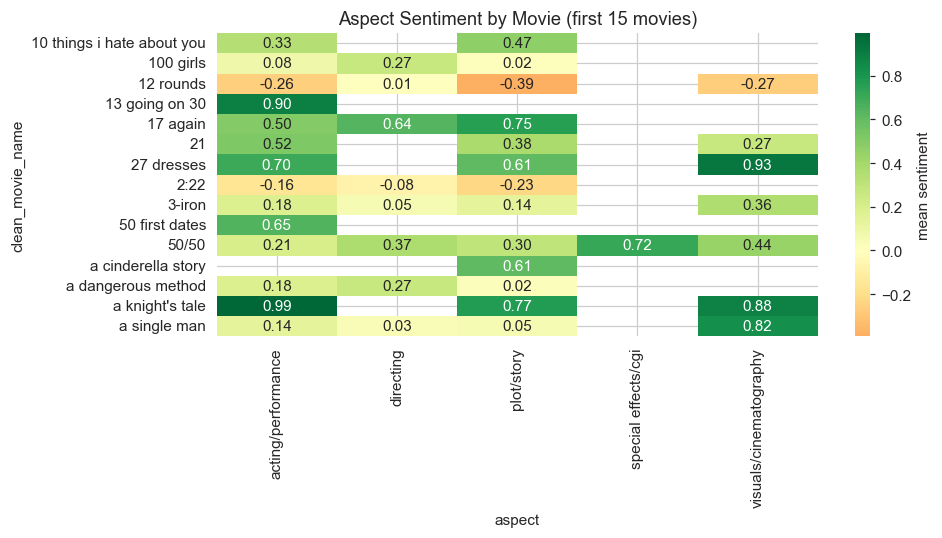

In [176]:
plt.figure(figsize=(9, 5))
sns.heatmap(movie_review_aspect.head(15), cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "mean sentiment"})
plt.title("Aspect Sentiment by Movie (first 15 movies)")
plt.tight_layout()
plt.show()

#### This heatmap gives us insights to the aspect sentiment by movie title. IMDB movie reviewers had higher positive sentiment for acting and performance in the movie 13 going on 30. Movie such as 17 again and a knight's tale had higher positive sentiment for plot and story. 

In [172]:
genres_of_interest_map = primary_genre_aspect.loc[genres_interest]

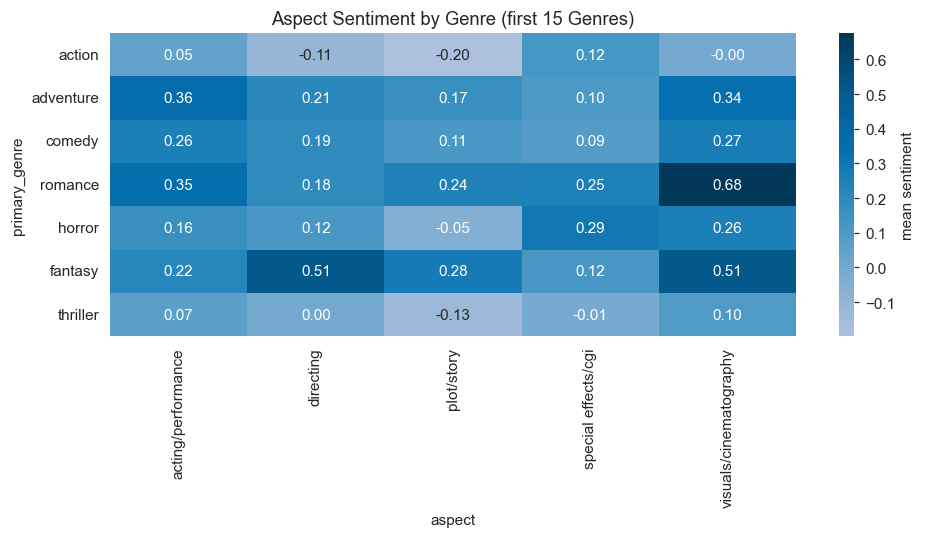

In [182]:
plt.figure(figsize=(9, 5))
sns.heatmap(genres_of_interest_map, cmap="PuBu", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "mean sentiment"})
plt.title("Aspect Sentiment by Genre (first 15 Genres)")
plt.tight_layout()
plt.show()

#### This heatmap gives us insights into aspect sentiment by genre. IMDB movie reviewers had an average higher positive sentiment for visuals and cinematography in genres such as fantasy and romance. As well there was a positive sentiment for acting and performance in genres such as romance and adventure. 